# Timeseries Classification
using a synthetic dataset

In [73]:
import time
import numpy as np
import matplotlib.pyplot as plt
from keras import Sequential, layers
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Generate Synthetic TimeSeries Dataset

In [109]:
N_SAMPLES   = 4000
TIMESTEPS   = 200
N_CHANNELS  = 2
N_CLASSES   = 4

In [110]:
def generate_timeseries(class_id, n_samples):
    X = np.zeros((n_samples, TIMESTEPS, N_CHANNELS))
    pulse = np.ones(20)
    for i in range(n_samples):
        signal = 0.5 * np.random.randn(TIMESTEPS)

        # ------------------------
        # Class 0 : (+,+)
        # ------------------------
        if class_id == 0:

            signal[10:30] += pulse
            signal[170:190] += pulse

        # ------------------------
        # Class 1 : (+,-)
        # ------------------------
        elif class_id == 1:

            signal[10:30] += pulse
            signal[170:190] -= pulse

        # ------------------------
        # Class 2 : (-,+)
        # ------------------------
        elif class_id == 2:

            signal[10:30] -= pulse
            signal[170:190] += pulse

        # ------------------------
        # Class 3 : Local burst
        # ------------------------
        else:

            burst = 2 * np.sin(
                np.linspace(0, 8*np.pi, 20)
            )

            signal[90:110] += burst

        # Channel 1
        X[i, :, 0] = signal

        # Channel 2 (noisy copy)
        X[i, :, 1] = (
            0.8 * signal +
            0.3 * np.random.randn(TIMESTEPS)
        )
    return X

### Generate Dataset

In [111]:
X = []
y = []

for cls in range(N_CLASSES):
    X_cls = generate_timeseries(
        cls,
        N_SAMPLES // N_CLASSES
    )
    y_cls = np.full(
        N_SAMPLES // N_CLASSES,
        cls
    )

    X.append(X_cls)
    y.append(y_cls)

X = np.concatenate(X)
y = np.concatenate(y)

# Shuffle
idx = np.random.permutation(len(X))
X = X[idx]
y = y[idx]

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.1,
    stratify=y,
    random_state=42
)

y_train_cat = to_categorical(y_train, N_CLASSES)
y_test_cat  = to_categorical(y_test, N_CLASSES)

In [113]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (3600, 200, 2)
X_test : (400, 200, 2)


In [114]:
y_train_cat[:7]

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.]])

### Visualize One Sample From Each Class

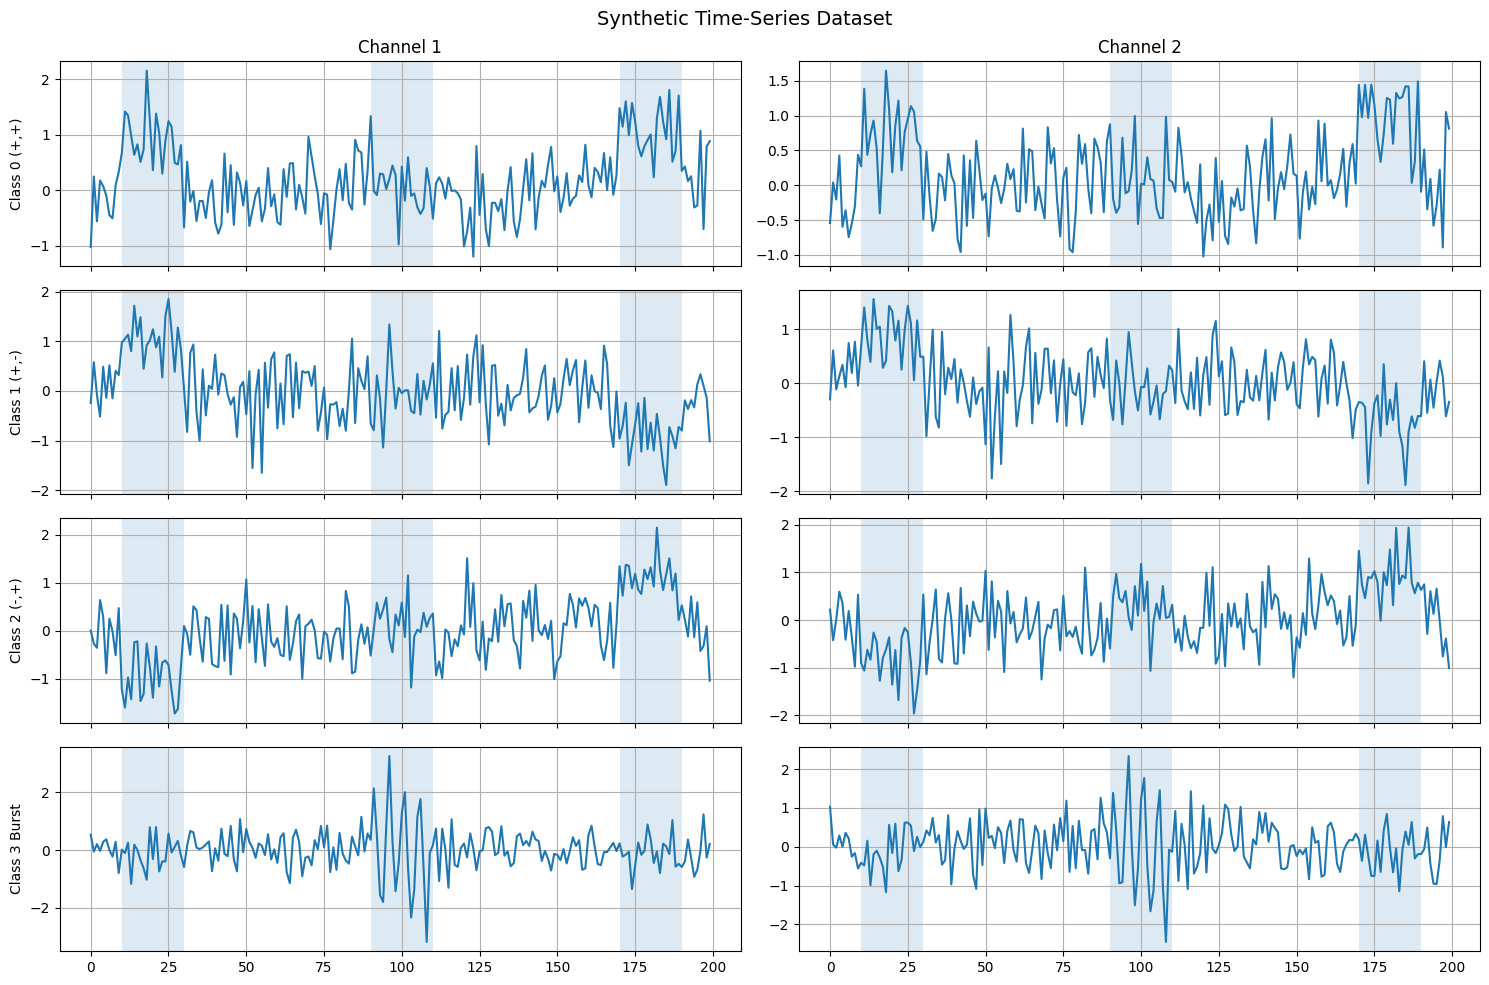

In [115]:
fig, axes = plt.subplots(
    N_CLASSES,
    N_CHANNELS,
    figsize=(15, 10),
    sharex=True
)

class_names = [
    "Class 0 (+,+)",
    "Class 1 (+,-)",
    "Class 2 (-,+)",
    "Class 3 Burst"
]

for cls in range(N_CLASSES):
    sample = generate_timeseries(cls, 1)[0]
    for ch in range(N_CHANNELS):

        ax = axes[cls, ch]
        ax.plot(sample[:, ch])
        ax.axvspan(10, 30, alpha=0.15)
        ax.axvspan(90, 110, alpha=0.15)
        ax.axvspan(170, 190, alpha=0.15)
        if cls == 0:
            ax.set_title(f"Channel {ch+1}")
        if ch == 0:
            ax.set_ylabel(class_names[cls])
        ax.grid(True)
plt.suptitle(
    "Synthetic Time-Series Dataset",
    fontsize=14
)
plt.tight_layout()
plt.show()

## Model Design

### MLP Model

In [116]:
model_mlp = Sequential([
    layers.Input(shape=(TIMESTEPS, N_CHANNELS,)),
    layers.Flatten(),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(8, activation='relu'),
    layers.Dense(N_CLASSES, activation='softmax'),
], name='MLP')

model_mlp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_mlp.summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 16)                  │           6,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 4)                   │              36 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,588 (25.73 KB)

 Trainable params: 6,588 (25.73 KB)

 Non-trainable params: 0 (0.00 B)

### CNN Model

In [117]:
model_cnn = Sequential([
    layers.Input(shape=(TIMESTEPS, N_CHANNELS)),
    layers.Conv1D(16, 20, padding='causal', activation='relu'),
    layers.Conv1D(32, 20, padding='causal', activation='relu'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation='relu'),
    layers.Dense(N_CLASSES, activation='softmax'),
], name='CNN')

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)                   │ (None, 200, 16)             │             656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_11 (Conv1D)                   │ (None, 200, 32)             │          10,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_5           │ (None, 32)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 4)                   │              68 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,524 (45.02 KB)

 Trainable params: 11,524 (45.02 KB)

 Non-trainable params: 0 (0.00 B)

### RNN Model

In [118]:
model_rnn = Sequential([
    layers.Input(shape=(TIMESTEPS, N_CHANNELS)),
    layers.GRU(16, return_sequences=True, recurrent_dropout=0.1),
    layers.GRU(16),
    layers.Dropout(0.1),
    layers.Dense(8, activation='relu'),
    layers.Dense(N_CLASSES, activation='softmax'),
], name='RNN')

model_rnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_rnn.summary()

Model: "RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_13 (GRU)                         │ (None, 200, 16)             │             960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_14 (GRU)                         │ (None, 16)                  │           1,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ (None, 4)                   │              36 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,764 (10.80 KB)

 Trainable params: 2,764 (10.80 KB)

 Non-trainable params: 0 (0.00 B)

## Train Models

In [119]:
EPOCHS = 20
BATCH_SIZE = 256

In [ ]:
print('Training MLP Model...')
start = time.time()
history_mlp = model_mlp.fit(X_train, y_train_cat,
                            epochs=EPOCHS, batch_size=BATCH_SIZE,
                            validation_split=0.2, verbose=0)
elapsed = time.time() - start
print(f'Final val accuracy: {history_mlp.history['val_accuracy'][-1]:.3f}',
      f'| Training time: {elapsed:.2f}')

print('Training CNN Model...')
start = time.time()
history_cnn = model_cnn.fit(X_train, y_train_cat,
                            epochs=EPOCHS, batch_size=BATCH_SIZE,
                            validation_split=0.2, verbose=0)
elapsed = time.time() - start
print(f'Final val accuracy: {history_cnn.history['val_accuracy'][-1]:.3f}',
      f'| Training time: {elapsed:.2f}')

print('Training RNN Model...')
start = time.time()
history_rnn = model_rnn.fit(X_train, y_train_cat,
                            epochs=EPOCHS, batch_size=BATCH_SIZE,
                            validation_split=0.2, verbose=0)
elapsed = time.time() - start
print(f'Final val accuracy: {history_rnn.history['val_accuracy'][-1]:.3f}',
      f'| Training time: {elapsed:.2f}')

Training MLP Model...
Final val accuracy: 1.000
Training time: 3.44
Training CNN Model...
Final val accuracy: 1.000
Training time: 5.99
Training RNN Model...
Final val accuracy: 0.746 | Training time: 31.72


## Evaluation

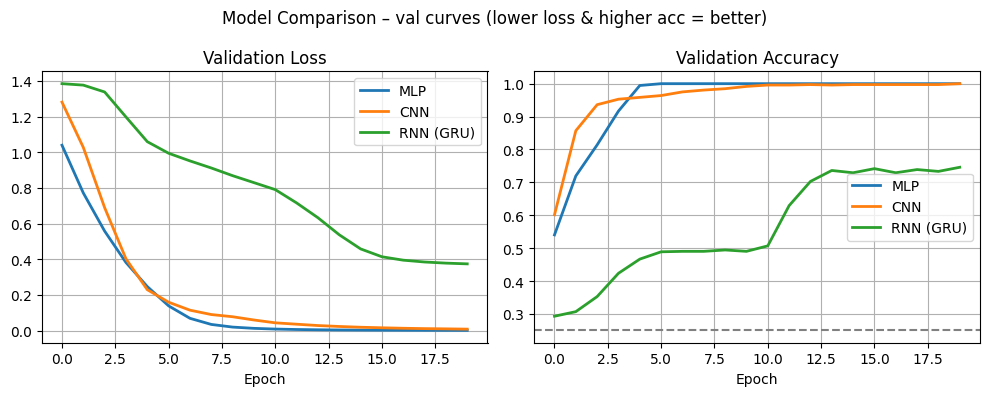

In [121]:
models_hist = {"MLP": history_mlp, "CNN": history_cnn, "RNN (GRU)": history_rnn}
colors      = {"MLP": "C0",        "CNN": "C1",        "RNN (GRU)": "C2"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for name, hist in models_hist.items():
    axes[0].plot(hist.history["val_loss"],     label=name, color=colors[name], lw=2)
    axes[1].plot(hist.history["val_accuracy"], label=name, color=colors[name], lw=2)

axes[0].set_title("Validation Loss");     axes[0].set_xlabel("Epoch"); axes[0].grid(True); axes[0].legend()
axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].grid(True); axes[1].legend()
axes[1].axhline(1/N_CLASSES, color="gray", linestyle="--", label="Random chance")
plt.suptitle("Model Comparison – val curves (lower loss & higher acc = better)")
plt.tight_layout()
plt.show()

-------MLP-------
-------CNN-------
-------RNN (GRU)-------


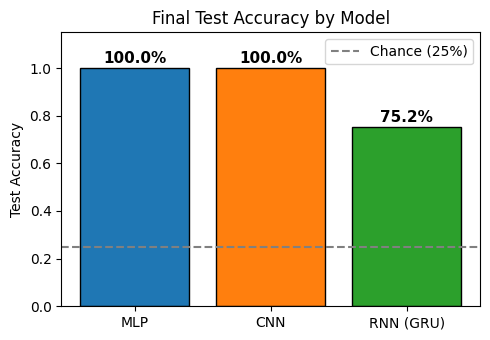

In [122]:
test_accs = {}
for name, (model, X_in) in zip(
        models_hist.keys(),
        [(model_mlp, X_test), (model_cnn, X_test), (model_rnn, X_test)]):
    print(f'-------{name}-------')
    preds = np.argmax(model.predict(X_in, verbose=0), axis=1)
    test_accs[name] = np.mean(preds == y_test)

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(test_accs.keys(), test_accs.values(),
              color=[colors[n] for n in test_accs], edgecolor="black")
ax.axhline(1/N_CLASSES, color="gray", linestyle="--", label=f"Chance ({1/N_CLASSES:.0%})")
ax.set_ylim(0, 1.15); ax.set_ylabel("Test Accuracy"); ax.set_title("Final Test Accuracy by Model")
for bar, val in zip(bars, test_accs.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.1%}", ha="center", fontsize=11, fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

In [123]:
y_pred_mlp = np.argmax(model_mlp.predict(X_test, verbose=0), axis=1)
y_pred_cnn = np.argmax(model_cnn.predict(X_test, verbose=0), axis=1)
y_pred_rnn = np.argmax(model_rnn.predict(X_test, verbose=0), axis=1)

print('------------MLP Model------------')
print(classification_report(y_test, y_pred_mlp))

print('------------CNN Model------------')
print(classification_report(y_test, y_pred_cnn))

print('------------RNN Model------------')
print(classification_report(y_test, y_pred_rnn))

------------MLP Model------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00       100

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

------------CNN Model------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00       100

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

------------RNN Model------------
              precision    r

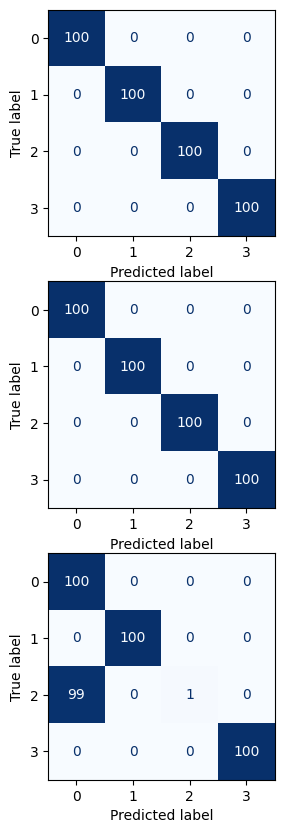

In [124]:
fig, axes = plt.subplots(3, 1, figsize=(5, 10))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
cm_rnn = confusion_matrix(y_test, y_pred_rnn)

disp_mlp = ConfusionMatrixDisplay(cm_mlp)
disp_mlp.plot(ax=axes[0], colorbar=False, cmap='Blues')

disp_cnn = ConfusionMatrixDisplay(cm_cnn)
disp_cnn.plot(ax=axes[1], colorbar=False, cmap='Blues')

disp_rnn = ConfusionMatrixDisplay(cm_rnn)
disp_rnn.plot(ax=axes[2], colorbar=False, cmap='Blues')

plt.show()